<a href="https://colab.research.google.com/github/kush450629/ME421_GROUP_A1/blob/main/Twin_rotor/E20051_Twin_Rotor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Twin Rotor System Symbolic Model
import sympy as sp

alpha, beta = sp.symbols('alpha beta', real=True)
u1, u2 = sp.symbols('u1 u2', real=True)

# Angular momentum and angular velocity
pi1, pi2, pi3 = sp.symbols('pi1 pi2 pi3', real=True)
omega1, omega2, omega3 = sp.symbols('omega1 omega2 omega3', real=True)

# Inertia matrix (diagonal body inertia assumed)
I1, I2, I3 = sp.symbols('I1 I2 I3', positive=True)

# Rotation Matrix R (generic symbolic 3x3)
R = sp.Matrix(sp.symbols('R11:14 R21:24 R31:34')).reshape(3,3)

# Skew symmetric (hat) operator
def hat(w):
    return sp.Matrix([
        [0,      -w[2],  w[1]],
        [w[2],   0,     -w[0]],
        [-w[1],  w[0],   0]
    ])

omega = sp.Matrix([omega1, omega2, omega3])
pi = sp.Matrix([pi1, pi2, pi3])

# 1) Kinematics: Rdot = hat(omega) R
Rdot = hat(omega) * R

# 2) Angular velocity relation ω = I^(-1) π
I = sp.diag(I1, I2, I3)
omega_from_pi = I.inv() * pi

# 3) Control torque τ^u
B = sp.Matrix([
    [1, 0],
    [0, 0],
    [0, 1]
])

M = sp.Matrix([
    [sp.cos(alpha), -sp.cos(beta)],
    [sp.sin(alpha), -sp.sin(beta)]
])

u = sp.Matrix([u1, u2])

tau_u = R * B * M * u

# 4) Constraint torque τ^e
T2 = sp.symbols('T2')

tau_e = R * sp.Matrix([0, T2, 0])

# 5) T2 expression
Omega = R.T * omega

cross_term = Omega.cross(I * Omega)
Omega_dot = sp.symbols('Omega1_dot Omega2_dot Omega3_dot')
Omega_dot_vec = sp.Matrix(Omega_dot)

dynamic_term = I * Omega_dot_vec

e2 = sp.Matrix([0,1,0])

T2_expression = e2.dot(cross_term + dynamic_term)

# =============================
# 6) Final dynamic equation
# =============================
tau_total = tau_u + tau_e

# =============================
# Display results
# =============================
print("Rdot =")
sp.pprint(Rdot)

print("\nomega = I^{-1} pi =")
sp.pprint(omega_from_pi)

print("\ntau_u =")
sp.pprint(sp.simplify(tau_u))

print("\ntau_e =")
sp.pprint(tau_e)

print("\nT2 expression =")
sp.pprint(T2_expression)

print("\npi_dot = tau_e + tau_u =")
sp.pprint(sp.simplify(tau_total))

Rdot =
⎡-R₂₁⋅ω₃ + R₃₁⋅ω₂  -R₂₂⋅ω₃ + R₃₂⋅ω₂  -R₂₃⋅ω₃ + R₃₃⋅ω₂⎤
⎢                                                    ⎥
⎢R₁₁⋅ω₃ - R₃₁⋅ω₁   R₁₂⋅ω₃ - R₃₂⋅ω₁   R₁₃⋅ω₃ - R₃₃⋅ω₁ ⎥
⎢                                                    ⎥
⎣-R₁₁⋅ω₂ + R₂₁⋅ω₁  -R₁₂⋅ω₂ + R₂₂⋅ω₁  -R₁₃⋅ω₂ + R₂₃⋅ω₁⎦

omega = I^{-1} pi =
⎡π₁⎤
⎢──⎥
⎢I₁⎥
⎢  ⎥
⎢π₂⎥
⎢──⎥
⎢I₂⎥
⎢  ⎥
⎢π₃⎥
⎢──⎥
⎣I₃⎦

tau_u =
⎡u₁⋅(R₁₁⋅cos(α) + R₁₃⋅sin(α)) - u₂⋅(R₁₁⋅cos(β) + R₁₃⋅sin(β))⎤
⎢                                                           ⎥
⎢u₁⋅(R₂₁⋅cos(α) + R₂₃⋅sin(α)) - u₂⋅(R₂₁⋅cos(β) + R₂₃⋅sin(β))⎥
⎢                                                           ⎥
⎣u₁⋅(R₃₁⋅cos(α) + R₃₃⋅sin(α)) - u₂⋅(R₃₁⋅cos(β) + R₃₃⋅sin(β))⎦

tau_e =
⎡R₁₂⋅T₂⎤
⎢      ⎥
⎢R₂₂⋅T₂⎥
⎢      ⎥
⎣R₃₂⋅T₂⎦

T2 expression =
I₁⋅(R₁₁⋅ω₁ + R₂₁⋅ω₂ + R₃₁⋅ω₃)⋅(R₁₃⋅ω₁ + R₂₃⋅ω₂ + R₃₃⋅ω₃) + I₂⋅Ω_2_dot - I₃⋅(R₁ ↪

↪ ₁⋅ω₁ + R₂₁⋅ω₂ + R₃₁⋅ω₃)⋅(R₁₃⋅ω₁ + R₂₃⋅ω₂ + R₃₃⋅ω₃)

pi_dot = tau_e + tau_u =
⎡R₁₂⋅T₂ + u₁⋅(R₁₁⋅cos(α) + R₁₃⋅sin(α)) - u₂⋅(R₁₁⋅cos(β) + R₁₃⋅sin(β))⎤
⎢                   

Task 2 : Simulate and animate the motion of the system for various different realistic inputs. For examle a vertical axis spin and a horizontal axis swing up and down motion.

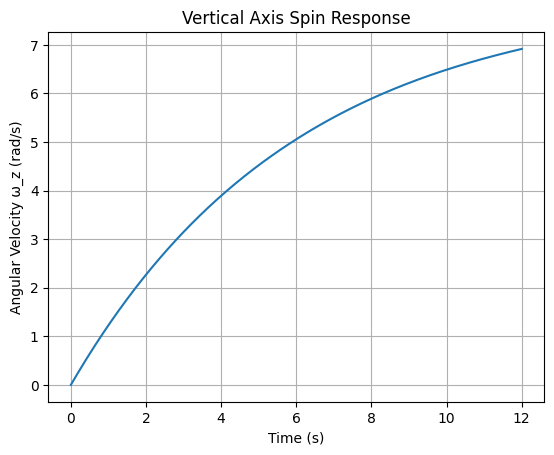

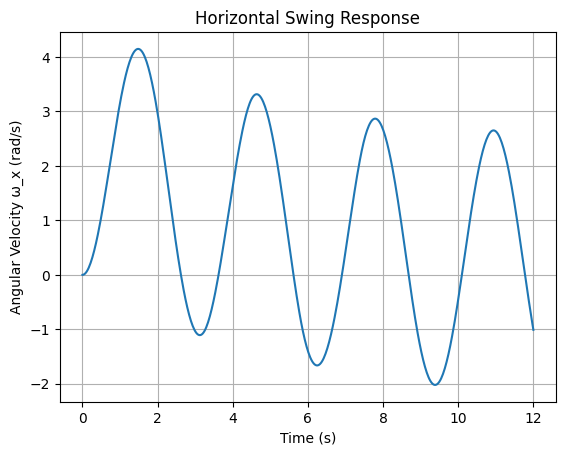

In [ ]:
# ============================================================
# Twin Rotor System Simulation
# Rigid-Body Rotational Dynamics
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 1. Physical Parameters (Realistic Lab-Scale Values)
# ------------------------------------------------------------

# Principal moments of inertia (kg*m^2)
I1 = 0.25
I2 = 0.40
I3 = 0.30

I = np.diag([I1, I2, I3])
I_inv = np.linalg.inv(I)

# Small viscous damping (realistic mechanical friction)
D = np.diag([0.05, 0.05, 0.05])

# ------------------------------------------------------------
# 2. Rigid Body Rotational Dynamics
# I*w_dot + w x (I w) + D w = tau
# ------------------------------------------------------------

def rigid_body_dynamics(t, omega, torque_func):
    omega = np.array(omega)
    tau = torque_func(t, omega)

    omega_dot = I_inv @ (
        tau
        - np.cross(omega, I @ omega)
        - D @ omega
    )

    return omega_dot


# ------------------------------------------------------------
# 3. Simulation Settings
# ------------------------------------------------------------

t_start = 0
t_end = 12
t_points = 500
t_eval = np.linspace(t_start, t_end, t_points)

omega_initial = [0, 0, 0]


# ============================================================
# SCENARIO 1: Vertical Axis Spin
# ============================================================

def torque_vertical_spin(t, omega):
    # Constant torque about Z axis
    return np.array([0.0, 0.0, 0.4])


solution_spin = solve_ivp(
    rigid_body_dynamics,
    (t_start, t_end),
    omega_initial,
    t_eval=t_eval,
    args=(torque_vertical_spin,)
)

plt.figure()
plt.plot(solution_spin.t, solution_spin.y[2])
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity ω_z (rad/s)")
plt.title("Vertical Axis Spin Response")
plt.grid(True)
plt.show()


# ============================================================
# SCENARIO 2: Horizontal Swing Motion
# ============================================================

def torque_swing(t, omega):
    # Oscillating torque about X axis
    return np.array([1.2 * np.sin(2*t), 0.0, 0.0])


solution_swing = solve_ivp(
    rigid_body_dynamics,
    (t_start, t_end),
    omega_initial,
    t_eval=t_eval,
    args=(torque_swing,)
)

plt.figure()
plt.plot(solution_swing.t, solution_swing.y[0])
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity ω_x (rad/s)")
plt.title("Horizontal Swing Response")
plt.grid(True)
plt.show()